# 233. Which pairs does the extended primitive find that the aligners miss?

Notebook 232 said a 10-residue HP seed with mismatch-tolerant extension reaches about a
third of 20-30%-identity pairs. The paper needs a different number: how many of those are
pairs phmmer and MMseqs2 do not find. On the Pfam identity panel MMseqs2 already sits at
0.41 at 25% identity, so "reaches 36%" is only a capability claim if a real share of it
is beyond the aligners.

Same pairs as notebook 232 (60,000 Pfam seed pairs, 11,998 SCOPe cross-family pairs).
Aligners (`scripts/aligner_pair_check.py`):

* phmmer 3.4, each pair on its own, `-Z 20000 --domZ 20000` so the E-value is what a
  proteome-sized database would give.
* MMseqs2 18, `-s 7.5`, all 116,176 segment sequences against themselves, E-value against
  that database.

A pair is found by an aligner at E <= 0.01. It is found by the extended primitive when its
best seeded segment score exceeds the composition-null 99.9th percentile (notebook 232's
per-comparison FPR 0.001, hp_thomas_dill2, seed 10, penalty 2). The two "found" criteria
are not the same kind of threshold: the aligner E-values are database-calibrated, the
kmerseek threshold is a per-pair composition null and is therefore the more lenient of
the two. Read the set difference as an upper bound on what the primitive adds, to be
confirmed by the search-engine run (`make run-midi-plus-extend`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc
import seed_extend_utils as se

pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)
FIG = Path("../figures")
E_CUT = 0.01
FPR = 1e-3
SEED, PENALTY, ALPHABET = 10, 2.0, "hp_thomas_dill2"

scores = hc.add_identity_bin(
    pl.read_parquet("/Users/olga/data/pfam/232_seed_extend_scores.parquet")
)
al = pl.read_parquet(
    "/Users/olga/data/pfam/233_aligner_check/233_aligner_pair_evalues.parquet"
)


def found_table(dataset):
    d = scores.filter(
        (pl.col("dataset") == dataset)
        & (pl.col("alphabet") == ALPHABET)
        & (pl.col("penalty") == PENALTY)
        & (pl.col("seed") == SEED)
    )
    thr = d.filter(pl.col("kind") != "real")["score"].quantile(
        1 - FPR, interpolation="higher"
    )
    real = d.filter(pl.col("kind") == "real").select(
        "query", "target", "seqid_ali", "identity_bin", "score"
    )
    out = real.join(
        al.filter(pl.col("dataset") == dataset).select(
            "query", "target", "phmmer_evalue", "mmseqs_evalue"
        ),
        on=["query", "target"],
        how="left",
    )
    return (
        out.with_columns(
            (pl.col("score") > thr).alias("kmerseek_ext"),
            (pl.col("phmmer_evalue") <= E_CUT).fill_null(False).alias("phmmer"),
            (pl.col("mmseqs_evalue") <= E_CUT).fill_null(False).alias("mmseqs2"),
        ).with_columns((pl.col("phmmer") | pl.col("mmseqs2")).alias("aligner")),
        thr,
    )


pf, thr_pf = found_table("pfam")
sc, thr_sc = found_table("scope")
print(f"kmerseek_ext threshold (score): Pfam {thr_pf:.0f}, SCOPe {thr_sc:.0f}")
for name, t in [("Pfam", pf), ("SCOPe cross-family", sc)]:
    print(
        name,
        t.height,
        "pairs; found:",
        {
            c: round(t[c].mean(), 3)
            for c in ["kmerseek_ext", "phmmer", "mmseqs2", "aligner"]
        },
    )

kmerseek_ext threshold (score): Pfam 22, SCOPe 16
Pfam 60000 pairs; found: {'kmerseek_ext': 0.62, 'phmmer': 0.843, 'mmseqs2': 0.765, 'aligner': 0.845}
SCOPe cross-family 11998 pairs; found: {'kmerseek_ext': 0.202, 'phmmer': 0.233, 'mmseqs2': 0.183, 'aligner': 0.235}


## 1. Found by whom, by identity bin

Four exclusive categories per pair: found by both the extended primitive and at least one
aligner; by the primitive only; by an aligner only; by neither.

Pfam seed
shape: (5, 5)
┌──────────────┬──────────────┬───────┬───────────────────┬─────────┐
│ identity_bin ┆ aligner only ┆ both  ┆ kmerseek_ext only ┆ neither │
│ ---          ┆ ---          ┆ ---   ┆ ---               ┆ ---     │
│ enum         ┆ f64          ┆ f64   ┆ f64               ┆ f64     │
╞══════════════╪══════════════╪═══════╪═══════════════════╪═════════╡
│ <20%         ┆ 0.121        ┆ 0.073 ┆ 0.047             ┆ 0.76    │
│ 20-30%       ┆ 0.418        ┆ 0.342 ┆ 0.012             ┆ 0.228   │
│ 30-40%       ┆ 0.346        ┆ 0.635 ┆ 0.0               ┆ 0.019   │
│ 40-60%       ┆ 0.117        ┆ 0.882 ┆ 0.0               ┆ 0.001   │
│ >=60%        ┆ 0.014        ┆ 0.986 ┆ 0.0               ┆ 0.0     │
└──────────────┴──────────────┴───────┴───────────────────┴─────────┘
SCOPe cross-family
shape: (4, 5)
┌──────────────┬──────────────┬───────┬───────────────────┬─────────┐
│ identity_bin ┆ aligner only ┆ both  ┆ kmerseek_ext only ┆ neither │
│ ---          ┆ ---          ┆ -

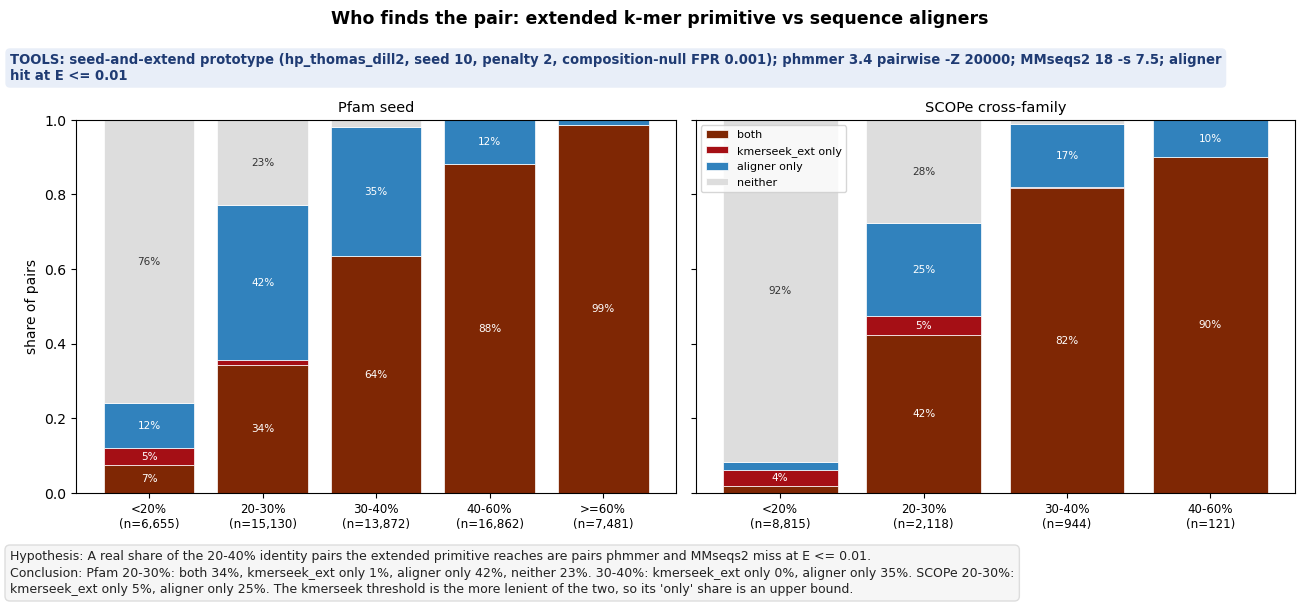

In [2]:
def categories(t):
    return (
        t.with_columns(
            pl.when(pl.col("kmerseek_ext") & pl.col("aligner"))
            .then(pl.lit("both"))
            .when(pl.col("kmerseek_ext"))
            .then(pl.lit("kmerseek_ext only"))
            .when(pl.col("aligner"))
            .then(pl.lit("aligner only"))
            .otherwise(pl.lit("neither"))
            .alias("cat")
        )
        .group_by("identity_bin", "cat")
        .len()
        .with_columns(
            (pl.col("len") / pl.col("len").sum().over("identity_bin")).alias("share")
        )
        .sort("identity_bin", "cat")
    )


CATS = ["both", "kmerseek_ext only", "aligner only", "neither"]
COL = {
    "both": "#7f2704",
    "kmerseek_ext only": "#a50f15",
    "aligner only": "#3182bd",
    "neither": "#dddddd",
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
tabs = {}
for ax, (name, t) in zip(axes, [("Pfam seed", pf), ("SCOPe cross-family", sc)]):
    c = categories(t)
    tabs[name] = c
    bins = [b for b in hc.IDENTITY_LABELS if b in c["identity_bin"].to_list()]
    bottom = np.zeros(len(bins))
    for cat in CATS:
        vals = np.array(
            [
                c.filter((pl.col("identity_bin") == b) & (pl.col("cat") == cat))[
                    "share"
                ].sum()
                for b in bins
            ]
        )
        ax.bar(
            range(len(bins)),
            vals,
            bottom=bottom,
            color=COL[cat],
            label=cat,
            edgecolor="white",
            lw=0.5,
        )
        for i, (v, bt) in enumerate(zip(vals, bottom)):
            if v > 0.04:
                ax.text(
                    i,
                    bt + v / 2,
                    f"{100 * v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    color="white" if cat != "neither" else "#333",
                )
        bottom += vals
    n_per = [t.filter(pl.col("identity_bin") == b).height for b in bins]
    ax.set_xticks(
        range(len(bins)), [f"{b}\n(n={n:,})" for b, n in zip(bins, n_per)], fontsize=8.5
    )
    ax.set_title(name, fontsize=10.5)
axes[0].set_ylabel("share of pairs")
axes[1].legend(fontsize=8, loc="upper left")
for name, c in tabs.items():
    print(name)
    print(
        c.with_columns(pl.col("share").round(3))
        .pivot(on="cat", index="identity_bin", values="share")
        .fill_null(0.0)
    )


def sh(name, b, cat):
    v = tabs[name].filter((pl.col("identity_bin") == b) & (pl.col("cat") == cat))[
        "share"
    ]
    return v[0] if v.len() else 0.0


hc.finish_figure(
    fig,
    FIG / "233_found_by_whom.png",
    tools=f"seed-and-extend prototype ({ALPHABET}, seed {SEED}, penalty {PENALTY:g}, composition-null FPR {FPR:g}); phmmer 3.4 pairwise -Z 20000; MMseqs2 18 -s 7.5; aligner hit at E <= {E_CUT}",
    hypothesis="A real share of the 20-40% identity pairs the extended primitive reaches are pairs phmmer and MMseqs2 miss at E <= 0.01.",
    conclusion=(
        f"Pfam 20-30%: both {100 * sh('Pfam seed', '20-30%', 'both'):.0f}%, kmerseek_ext only {100 * sh('Pfam seed', '20-30%', 'kmerseek_ext only'):.0f}%, aligner only {100 * sh('Pfam seed', '20-30%', 'aligner only'):.0f}%, neither {100 * sh('Pfam seed', '20-30%', 'neither'):.0f}%. "
        f"30-40%: kmerseek_ext only {100 * sh('Pfam seed', '30-40%', 'kmerseek_ext only'):.0f}%, aligner only {100 * sh('Pfam seed', '30-40%', 'aligner only'):.0f}%. "
        f"SCOPe 20-30%: kmerseek_ext only {100 * sh('SCOPe cross-family', '20-30%', 'kmerseek_ext only'):.0f}%, aligner only {100 * sh('SCOPe cross-family', '20-30%', 'aligner only'):.0f}%. The kmerseek threshold is the more lenient of the two, so its 'only' share is an upper bound."
    ),
    title="Who finds the pair: extended k-mer primitive vs sequence aligners",
)

## 2. Score against E-value on the same pairs

Each point is one 20-30%-identity Pfam pair: the extended segment score against the
phmmer E-value. Pairs at the top left are the ones the primitive adds; pairs at the
bottom right are what it loses.

shape: (4, 3)
┌──────────────┬────────┬──────┐
│ kmerseek_ext ┆ phmmer ┆ len  │
│ ---          ┆ ---    ┆ ---  │
│ bool         ┆ bool   ┆ u32  │
╞══════════════╪════════╪══════╡
│ false        ┆ false  ┆ 3513 │
│ false        ┆ true   ┆ 6250 │
│ true         ┆ false  ┆ 193  │
│ true         ┆ true   ┆ 5174 │
└──────────────┴────────┴──────┘
median phmmer E-value of kmerseek_ext-only pairs: 0.037


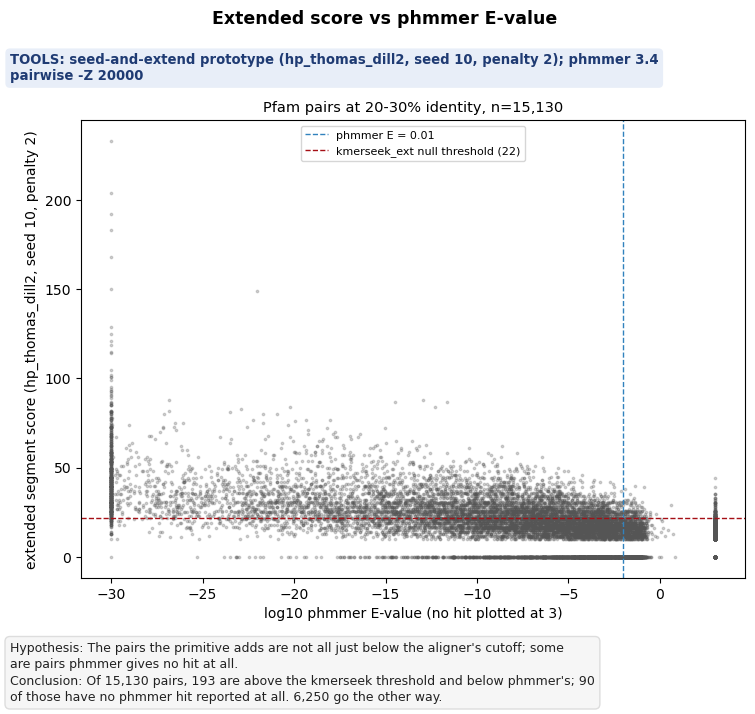

In [3]:
t = pf.filter(pl.col("identity_bin") == "20-30%")
fig, ax = plt.subplots(figsize=(7.5, 5.5))
x = t["phmmer_evalue"].fill_null(1e3).clip(1e-30, 1e3).to_numpy()
ax.scatter(np.log10(x), t["score"], s=3, alpha=0.25, color="#555555")
ax.axvline(np.log10(E_CUT), color="#3182bd", ls="--", lw=1, label=f"phmmer E = {E_CUT}")
ax.axhline(
    thr_pf,
    color="#a50f15",
    ls="--",
    lw=1,
    label=f"kmerseek_ext null threshold ({thr_pf:.0f})",
)
ax.set_xlabel("log10 phmmer E-value (no hit plotted at 3)")
ax.set_ylabel("extended segment score (hp_thomas_dill2, seed 10, penalty 2)")
ax.legend(fontsize=8)
ax.set_title(f"Pfam pairs at 20-30% identity, n={t.height:,}", fontsize=10.5)
q = t.with_columns((pl.col("phmmer_evalue").is_null()).alias("no_phmmer_hit"))
print(q.group_by("kmerseek_ext", "phmmer").len().sort("kmerseek_ext", "phmmer"))
print(
    "median phmmer E-value of kmerseek_ext-only pairs:",
    q.filter(pl.col("kmerseek_ext") & ~pl.col("phmmer"))["phmmer_evalue"].median(),
)
hc.finish_figure(
    fig,
    FIG / "233_score_vs_phmmer_evalue.png",
    tools=f"seed-and-extend prototype ({ALPHABET}, seed {SEED}, penalty {PENALTY:g}); phmmer 3.4 pairwise -Z 20000",
    hypothesis="The pairs the primitive adds are not all just below the aligner's cutoff; some are pairs phmmer gives no hit at all.",
    conclusion=(
        f"Of {t.height:,} pairs, {q.filter(pl.col('kmerseek_ext') & ~pl.col('phmmer')).height:,} are above the kmerseek threshold and below phmmer's; "
        f"{q.filter(pl.col('kmerseek_ext') & pl.col('no_phmmer_hit')).height:,} of those have no phmmer hit reported at all. "
        f"{q.filter(~pl.col('kmerseek_ext') & pl.col('phmmer')).height:,} go the other way."
    ),
    title="Extended score vs phmmer E-value",
)

## 3. Conclusions

1. The extended primitive is close to a subset of what the aligners find. Pfam seed pairs
   at 20-30% identity: found by both 34%, by an aligner only 42%, by the extended primitive
   only 1.2%, by neither 23%. At 30-40%: aligner only 35%, primitive only 0.0%. Under 20%:
   primitive only 4.7%, aligner only 12%. SCOPe cross-family at 20-30%: primitive only
   4.9%, aligner only 25%.
2. The primitive-only pairs are not beyond the aligners' reach, they are just below the
   cutoff: the 193 Pfam pairs at 20-30% that the primitive finds and phmmer does not have a
   median phmmer E-value of 0.037.
3. And this is with the primitive's threshold being the lenient one (a per-pair composition
   null at 0.001, against database-calibrated E-values at 0.01). The search-engine run can
   only make the set difference smaller.
4. What that means for the paper: the extension recovers what the exact k-mer lost (nb 232),
   not what the aligners lack. Together with nb 234 (HP retention per substitution sits on
   the BLOSUM62 line) the capability-unlock claim has no support in these pairs. The claim
   that survives is cost and placement: the same conservation, read with a cheaper
   primitive, and (nb 231, the QfO report) placed more precisely where it fires.